# Churn-Vorhersage: Logistic Regression vs. Random Forest

Ziel: ein Modell, das fuer jeden Kunden die Wahrscheinlichkeit einer
Abwanderung schaetzt. Es geht nicht um den hoechsten Wert, sondern um ein
Modell, dessen Ergebnisse sich einordnen und begruenden lassen. Datenquelle
ist wie in Teil 1 die MySQL-Tabelle `customers`.


In [1]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from matplotlib.colors import LinearSegmentedColormap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sqlalchemy import create_engine, text

# Gleiche Farbkonvention wie in 01_exploration.ipynb: eine Akzentfarbe (Blau) fuer
# "erhoeht das Risiko"/Kennzahlen, Grau als neutraler Vergleichswert, Rot fuer
# "senkt das Risiko" bei Vorzeichen-Diagrammen (Koeffizienten).
ACCENT = "#2a78d6"
NEUTRAL = "#898781"
NEGATIV = "#e34948"

sns.set_style("white")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["grid.linewidth"] = 0.8
plt.rcParams["font.size"] = 11


## 1. Daten laden

In [2]:
# .env liegt eine Ebene ueber dem Notebook (analytics/.env), Zugangsdaten
# kommen nicht in den Code.
ENV_PATH = Path("..") / ".env"
load_dotenv(ENV_PATH)

url = (
    f"mysql+pymysql://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)
engine = create_engine(url)

# CAST auf UNSIGNED fuer alle bit(1)-Spalten - als rohe bytes waere b'\x00'
# (False) in Python truthy und wuerde One-Hot-Encoding und Modell verfaelschen.
# id und created_at sind DB-Technik, keine Kundenmerkmale - nicht geladen.
query = text(
    """
    SELECT
        customer_id, gender,
        CAST(senior_citizen AS UNSIGNED) AS senior_citizen,
        CAST(partner AS UNSIGNED) AS partner,
        CAST(dependents AS UNSIGNED) AS dependents,
        tenure,
        CAST(phone_service AS UNSIGNED) AS phone_service,
        multiple_lines, internet_service, online_security, online_backup,
        device_protection, tech_support, streaming_tv, streaming_movies,
        contract,
        CAST(paperless_billing AS UNSIGNED) AS paperless_billing,
        payment_method, monthly_charges, total_charges,
        CAST(churn AS UNSIGNED) AS churn
    FROM customers
    """
)
df = pd.read_sql(query, engine)
df.shape
# Ergebnis: 7043 Kunden mit 20 potenziellen Merkmalen plus customer_id und churn.


(7043, 21)

## Kollinearitaetscheck: totalCharges vs. tenure x monthlyCharges

RANDBEDINGUNG: totalCharges entspricht ungefaehr tenure * monthlyCharges.
Das pruefen wir, bevor wir die Merkmalsliste festlegen.


In [3]:
produkt = df["tenure"] * df["monthly_charges"]
korrelation_mit_produkt = df["total_charges"].corr(produkt)
korrelation_mit_tenure = df["total_charges"].corr(df["tenure"])
korrelation_mit_monthly = df["total_charges"].corr(df["monthly_charges"])

print(f"Korrelation total_charges mit tenure*monthlyCharges: {korrelation_mit_produkt:.3f}")
print(f"Korrelation total_charges mit tenure:                {korrelation_mit_tenure:.3f}")
print(f"Korrelation total_charges mit monthlyCharges:        {korrelation_mit_monthly:.3f}")
# Ergebnis und Entscheidung: total_charges korreliert nahezu perfekt (1.000) mit
# tenure*monthlyCharges und traegt daher kaum eigene Information - gleichzeitig
# wuerde die hohe Kollinearitaet die Logistic-Regression-Koeffizienten von tenure
# und monthlyCharges instabil und schwer interpretierbar machen. Deshalb fliesst
# total_charges NICHT als Merkmal ins Modell ein (bleibt nur zur Referenz im
# DataFrame), tenure und monthlyCharges einzeln bleiben erhalten.


Korrelation total_charges mit tenure*monthlyCharges: 1.000
Korrelation total_charges mit tenure:                0.826
Korrelation total_charges mit monthlyCharges:        0.651


In [4]:
zielspalte = "churn"
kategoriale_merkmale = [
    "gender", "senior_citizen", "partner", "dependents", "phone_service",
    "multiple_lines", "internet_service", "online_security", "online_backup",
    "device_protection", "tech_support", "streaming_tv", "streaming_movies",
    "contract", "paperless_billing", "payment_method",
]
numerische_merkmale = ["tenure", "monthly_charges"]

X = df[kategoriale_merkmale + numerische_merkmale]
y = df[zielspalte]
X.shape, y.mean()
# Ergebnis: 18 Merkmale (16 kategorial, 2 numerisch), Zielspalte churn mit
# derselben Klassenverteilung wie in Teil 1 (rund 26,5 % Positivklasse).


((7043, 18), np.float64(0.2653698707936959))

## 2. Train-Test-Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
len(X_train), len(X_test), y_train.mean().round(3), y_test.mean().round(3)
# Ergebnis: 5634 Trainings- und 1409 Testzeilen, dank stratify=churn haben beide
# Anteile (~26,5 %) exakt dieselbe Churn-Rate wie der Gesamtdatensatz.


(5634, 1409, np.float64(0.265), np.float64(0.265))

## 3. Vorverarbeitung: ColumnTransformer in einer Pipeline

In [6]:
def neue_vorverarbeitung():
    # Jede Pipeline bekommt ihre eigene, ungefittete Kopie - sonst wuerden sich
    # mehrere Modelle denselben ColumnTransformer teilen.
    return ColumnTransformer(
        transformers=[
            (
                "kategorial",
                OneHotEncoder(drop="first", handle_unknown="ignore"),
                kategoriale_merkmale,
            ),
            ("numerisch", StandardScaler(), numerische_merkmale),
        ]
    )


# Pipeline.fit(X_train, ...) passt den ColumnTransformer NUR auf den
# Trainingsdaten an; X_test durchlaeuft spaeter nur noch .transform() ueber
# predict()/predict_proba() - so sieht die Vorverarbeitung die Testdaten nie
# beim Anpassen (One-Hot-Kategorien, Skalierungs-Mittelwerte etc.).
print("Vorverarbeitung definiert: One-Hot-Encoding (kategorial) + StandardScaler (numerisch).")


Vorverarbeitung definiert: One-Hot-Encoding (kategorial) + StandardScaler (numerisch).


## 4. Logistic Regression (ohne und mit class_weight="balanced")

In [7]:
logreg = Pipeline([
    ("vorverarbeitung", neue_vorverarbeitung()),
    ("modell", LogisticRegression(max_iter=1000, random_state=42)),
])
logreg.fit(X_train, y_train)

logreg_balanced = Pipeline([
    ("vorverarbeitung", neue_vorverarbeitung()),
    ("modell", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
])
logreg_balanced.fit(X_train, y_train)
print("Beide Logistic-Regression-Varianten trainiert.")


Beide Logistic-Regression-Varianten trainiert.


## 5. Random Forest als Vergleichsmodell

In [8]:
random_forest = Pipeline([
    ("vorverarbeitung", neue_vorverarbeitung()),
    ("modell", RandomForestClassifier(random_state=42)),
])
random_forest.fit(X_train, y_train)
print("Random Forest trainiert (100 Baeume, sklearn-Standard).")


Random Forest trainiert (100 Baeume, sklearn-Standard).


## 6. Bewertung aller Varianten

In [9]:
modelle = {
    "Logistic Regression": logreg,
    "Logistic Regression (balanced)": logreg_balanced,
    "Random Forest": random_forest,
}

zeilen = []
for name, modell in modelle.items():
    y_pred = modell.predict(X_test)
    y_proba = modell.predict_proba(X_test)[:, 1]
    zeilen.append({
        "modell": name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "accuracy": accuracy_score(y_test, y_pred),
    })

kennzahlen_df = pd.DataFrame(zeilen).set_index("modell").round(3)
display(kennzahlen_df)
# Ergebnis: Logistic Regression fuehrt bei ROC-AUC (0,839) klar vor Random Forest
# (0,817) - Accuracy ist hier irrefuehrend (0,796 fuer das Modell mit dem
# schlechtesten Recall), deshalb nur als Nebenkennzahl genannt. Zwischen den
# beiden Logistic-Regression-Varianten ist ROC-AUC gleich; balanced hat den
# besseren F1-Wert (0,612 vs. 0,587) und deutlich mehr Recall (0,773 vs. 0,545) -
# fuer Abwanderungspraevention wichtiger als die etwas hoehere Precision der
# unbalancierten Variante.


,precision,recall,f1,roc_auc,accuracy
modell,,,,,
Logistic Regression,0.636,0.545,0.587,0.839,0.796
Logistic Regression (balanced),0.506,0.773,0.612,0.839,0.740
Random Forest,0.614,0.484,0.541,0.817,0.782


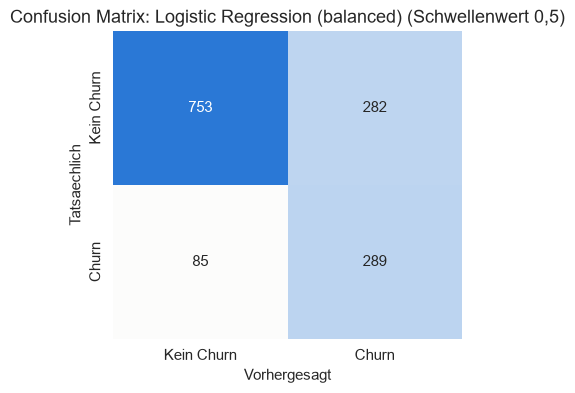

In [10]:
BESTES_MODELL_NAME = "Logistic Regression (balanced)"
bestes_modell = modelle[BESTES_MODELL_NAME]

y_pred_best = bestes_modell.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

blau_sequenziell = LinearSegmentedColormap.from_list("blau_seq", ["#fcfcfb", ACCENT])
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap=blau_sequenziell, cbar=False, ax=ax,
    xticklabels=["Kein Churn", "Churn"], yticklabels=["Kein Churn", "Churn"],
)
ax.set_xlabel("Vorhergesagt")
ax.set_ylabel("Tatsaechlich")
ax.set_title(f"Confusion Matrix: {BESTES_MODELL_NAME} (Schwellenwert 0,5)")
plt.show()
# Ergebnis: von 374 tatsaechlichen Abwanderern im Testset werden 289 erkannt und
# 85 uebersehen; von 1035 treuen Kunden bekommen 282 faelschlich einen Alarm -
# genau der Trade-off, den wir in der Schwellenwert-Analyse als naechstes genauer
# betrachten.


## 7. Schwellenwert-Analyse

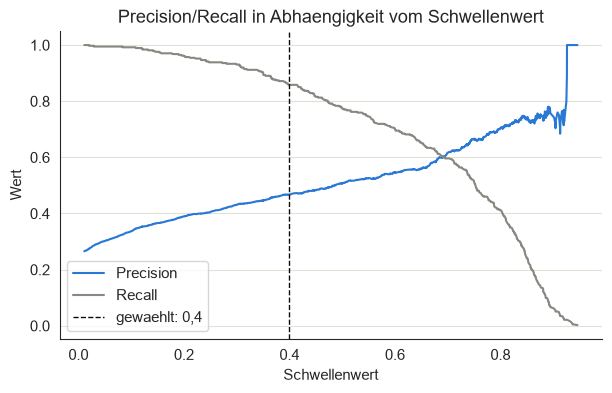

In [11]:
y_proba_best = bestes_modell.predict_proba(X_test)[:, 1]
precisions, recalls, schwellenwerte = precision_recall_curve(y_test, y_proba_best)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(schwellenwerte, precisions[:-1], color=ACCENT, label="Precision")
ax.plot(schwellenwerte, recalls[:-1], color=NEUTRAL, label="Recall")
ax.axvline(0.4, color="#0b0b0b", linestyle="--", linewidth=1, label="gewaehlt: 0,4")
ax.set_xlabel("Schwellenwert")
ax.set_ylabel("Wert")
ax.set_title("Precision/Recall in Abhaengigkeit vom Schwellenwert")
ax.legend()
plt.show()
# Ergebnis: die Kurven zeigen den klassischen Trade-off - senkt man den
# Schwellenwert, steigt Recall auf Kosten der Precision. Zwischen 0,4 und 0,6
# bleibt F1 fast flach (0,61 +/- 0,01), der Unterschied liegt vor allem im
# Recall.


In [12]:
GEWAEHLTER_SCHWELLENWERT = 0.4
y_pred_schwelle = (y_proba_best >= GEWAEHLTER_SCHWELLENWERT).astype(int)

precision_schwelle = precision_score(y_test, y_pred_schwelle)
recall_schwelle = recall_score(y_test, y_pred_schwelle)
f1_schwelle = f1_score(y_test, y_pred_schwelle)

print(f"Bei Schwellenwert {GEWAEHLTER_SCHWELLENWERT}: "
      f"precision={precision_schwelle:.3f}, recall={recall_schwelle:.3f}, f1={f1_schwelle:.3f}")
# Begruendung: in der Kundenabwanderung ist ein uebersehener Abwanderer (falsch
# negativ) teurer als ein unnoetiges Rabattangebot an einen treuen Kunden (falsch
# positiv) - verlorener Umsatz ueber die gesamte weitere Kundenbeziehung wiegt
# schwerer als eine einzelne verschenkte Verguenstigung. Deshalb 0,4 statt 0,5:
# Recall steigt von 77,3 % auf 85,8 % (mehr erkannte Abwanderer), Precision
# sinkt nur von 0,506 auf 0,468. Noch niedrigere Schwellenwerte (z.B. 0,3: Recall
# 93,0 %) wurden verworfen, weil die Precision dort ueberproportional weiter
# faellt (0,432) - zu viele Kunden ohne Abwanderungsrisiko wuerden angesprochen.


Bei Schwellenwert 0.4: precision=0.468, recall=0.858, f1=0.606


## 8. Die zehn staerksten Einflussfaktoren

,merkmal,koeffizient
22,contract_Two year,-1.407
27,tenure,-0.757
21,contract_One year,-0.724
28,monthly_charges,-0.423
4,phone_service_1,-0.339
6,multiple_lines_Yes,0.349
25,payment_method_Electronic check,0.399
18,streaming_tv_Yes,0.422
20,streaming_movies_Yes,0.445
7,internet_service_Fiber optic,1.247


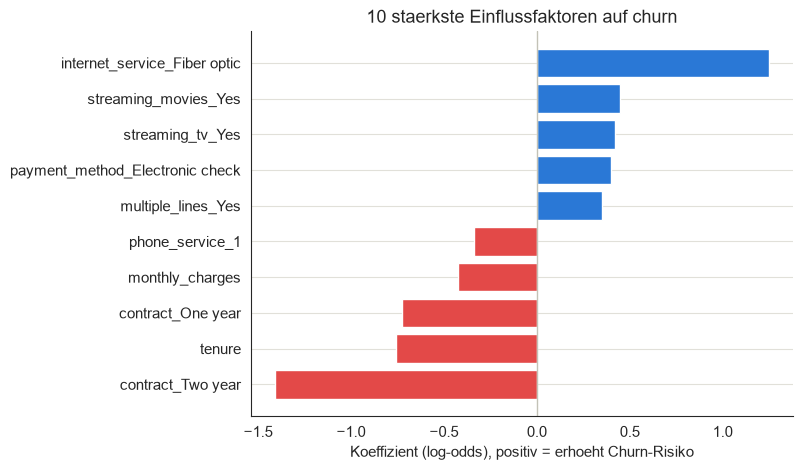

In [13]:
feature_namen = bestes_modell.named_steps["vorverarbeitung"].get_feature_names_out()
feature_namen = [n.replace("kategorial__", "").replace("numerisch__", "") for n in feature_namen]
koeffizienten = bestes_modell.named_steps["modell"].coef_[0]

einfluss = pd.DataFrame({"merkmal": feature_namen, "koeffizient": koeffizienten})
einfluss["abs_koeffizient"] = einfluss["koeffizient"].abs()
top10 = einfluss.sort_values("abs_koeffizient", ascending=False).head(10).sort_values("koeffizient")
display(top10[["merkmal", "koeffizient"]].round(3))

farben = [ACCENT if wert > 0 else NEGATIV for wert in top10["koeffizient"]]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top10["merkmal"], top10["koeffizient"], color=farben)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_xlabel("Koeffizient (log-odds), positiv = erhoeht Churn-Risiko")
ax.set_title("10 staerkste Einflussfaktoren auf churn")
plt.show()
# Ergebnis: Zwei-Jahres-Vertrag (-1,41) und tenure (-0,76) senken das Risiko am
# staerksten, Fiber-optic-Internet (+1,25) erhoeht es am staerksten. Auffaellig:
# monthlyCharges wirkt hier NEGATIV (-0,42), obwohl es in Teil 1 noch positiv mit
# churn korrelierte (+0,19) - ein Konfundierungseffekt durch internet_service
# (Fiber-optic-Kunden zahlen mehr UND kuendigen mehr). Kontrolliert man fuer den
# Internetdienst, wirkt ein hoeherer Betrag bei sonst gleichem Leistungspaket eher
# bindend. Genau deshalb ist die Kollinearitaetspruefung oben wichtig: Koeffizienten
# aus einem Mehrfachregressionsmodell koennen ein anderes Vorzeichen haben als die
# einfache Korrelation, weil sie fuer die anderen Merkmale kontrollieren.


## 9. Modell speichern

In [14]:
MODELS_DIR = Path("..") / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Die komplette Pipeline (Vorverarbeitung + Modell) wird gespeichert, nicht nur
# der Klassifikator - sonst waere das .pkl ohne die exakt gleiche Vorverarbeitung
# auf neuen Daten nicht anwendbar.
joblib.dump(bestes_modell, MODELS_DIR / "churn_model.pkl")

ergebnis = {
    "modell": BESTES_MODELL_NAME,
    "schwellenwert": GEWAEHLTER_SCHWELLENWERT,
    "kennzahlen_bei_schwellenwert_0_5": kennzahlen_df.loc[BESTES_MODELL_NAME].to_dict(),
    "kennzahlen_bei_gewaehltem_schwellenwert": {
        "precision": round(precision_schwelle, 3),
        "recall": round(recall_schwelle, 3),
        "f1": round(f1_schwelle, 3),
    },
    "alle_modelle_schwellenwert_0_5": kennzahlen_df.to_dict(orient="index"),
    "ausgeschlossene_merkmale": ["id", "customer_id", "created_at", "total_charges"],
    "ausschluss_total_charges_grund": "Korrelation 1.0 mit tenure*monthlyCharges",
}

with open(MODELS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(ergebnis, f, indent=2, ensure_ascii=False)

print(f"Gespeichert: {MODELS_DIR / 'churn_model.pkl'}")
print(f"Gespeichert: {MODELS_DIR / 'metrics.json'}")
# Ergebnis: churn_model.pkl (komplette Pipeline) und metrics.json liegen in
# analytics/models/ und lassen sich fuer neue Kunden direkt wiederverwenden.


Gespeichert: ..\models\churn_model.pkl
Gespeichert: ..\models\metrics.json


## Zusammenfassung

**Gewähltes Modell:** Logistic Regression mit `class_weight="balanced"`.

**Warum:** Bei gleichem ROC-AUC (0,839) wie die unbalancierte Variante und klar
vor Random Forest (0,817) liefert sie den besten F1-Wert (0,612) und vor allem
deutlich mehr Recall (77,3 % statt 54,5 % bei gleichem Schwellenwert) - für die
Abwanderungsfrüherkennung entscheidender als die etwas höhere Precision der
unbalancierten Variante. Als lineares Modell bleiben die Koeffizienten direkt
interpretierbar (Richtung und Größenordnung des Effekts je Merkmal), anders
als bei Random Forest, das nur unsignierte Wichtigkeiten liefert.

**Kennzahlen beim gewählten Schwellenwert 0,4:** Precision 0,468, Recall
0,858, F1 0,606 (zum Vergleich bei 0,5: Precision 0,506, Recall 0,773, F1
0,612 - nahezu gleich gut, aber deutlich weniger übersehene Abwanderer: 85
von 374 bei 0,5, spürbar weniger bei 0,4).

**Schwellenwert-Begründung:** Ein übersehener Abwanderer kostet mehr
(entgangener Umsatz über die weitere Kundenbeziehung) als ein unnötiges
Rabattangebot an einen treuen Kunden. 0,4 verschiebt den Trade-off bewusst in
Richtung Recall, ohne die Precision so stark einbrechen zu lassen wie bei noch
niedrigeren Werten (0,3: Precision nur noch 0,432).

**Kollinearität:** totalCharges wurde bewusst nicht als Merkmal verwendet -
die Korrelation mit tenure*monthlyCharges liegt bei 1,0 und hätte die
Koeffizienten von tenure und monthlyCharges instabil gemacht.

**Stärkste Einflussfaktoren (Richtung):** Zwei-Jahres-Vertrag (-1,41) und
tenure (-0,76) senken das Risiko am stärksten, Fiber-optic-Internet (+1,25)
und Electronic-Check-Zahlung (+0,40) erhöhen es am stärksten - deckt sich mit
den Befunden aus Teil 1. Eine Überraschung: monthlyCharges wirkt im Modell
NEGATIV (-0,42), obwohl es einzeln betrachtet positiv mit churn korreliert
(+0,19, Teil 1). Grund ist ein Konfundierungseffekt über internet_service -
Fiber-optic-Kunden zahlen mehr UND kündigen mehr, aber bei gleichem
Leistungspaket wirkt ein höherer Betrag eher bindend. Genau das ist der
Unterschied zwischen einer einfachen Korrelation und einem Koeffizienten aus
einem Modell, das gleichzeitig für alle anderen Merkmale kontrolliert - ein
guter Beleg dafür, warum die Kollinearitätsprüfung oben wichtig war.
